# `GEA` demo: a Disease Graph Atlas from DisGeNET + STRING

**Part 1 — data extraction and graph construction.**

The GEA tutorials so far build *sample-specific* networks (LIONESS co-expression + STRING prior),
where one graph = one biological sample. That works well for the node- and edge-level SAEs, but the
graph-level SAE has little to say: "properties of one LIONESS artefact" is hard to name biologically.

This notebook builds the alternative dataset — the **Disease Graph Atlas** — in which

$$\text{one graph} \;=\; \text{one disease}$$

$$G_d = (V_d,\; E_d,\; X_d,\; W_d)$$

| symbol | content | source |
|---|---|---|
| $V_d$ | protein-coding genes associated with disease $d$ | DisGeNET gene–disease associations |
| $E_d$ | interactions **among those genes** (induced subgraph, no 1-hop expansion yet) | STRING |
| $X_d$ | node features: disease-association evidence $\Vert$ ESM-2 protein embedding | DisGeNET + ESM-2 |
| $W_d$ | edge weights: STRING confidence $s_{ij}/1000$ | STRING |

Gene identity travels with the node through its ESM-2 embedding ("*what is this protein*"), while the
graph supplies the disease context ("*what is it doing here*"). That is why variable node sets across
diseases are acceptable: nodes do not need a shared index to be comparable.

**Scope of this notebook (Part 1):** disease universe → DisGeNET retrieval → QC → gene filtering →
gene→protein mapping → STRING backbone → ESM node features → PyG graphs → graph QC → export.
Deliberately *no* model: the GCN, the three SAEs and the interpretation experiments come in Part 2,
so that any weirdness later can be attributed to the model rather than the dataset.

**Deliberately simple baseline.** Induced subgraph only (no 1-hop expansion), STRING confidence as a
single edge weight, one gene set per disease. Network expansion, GRN edges and multi-evidence seed
sets are follow-up ablations, not part of the first dataset.

## 0 — Configuration

In [28]:
import gzip
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import torch
from tqdm.auto import tqdm

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data/disgenet")
RAW_DIR    = DATA_DIR / "raw_gda"          # one JSON per disease, exactly as returned by the API
STRING_DIR = DATA_DIR / "string"           # STRING bulk downloads (cached, ~160 MB)
for d in (DATA_DIR, RAW_DIR, STRING_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Where the disease→gene seed sets come from:
#   "disgenet" — DisGeNET REST API v1 (needs a free academic API key, section 2)
#   "diseases" — Jensen-lab DISEASES (no key, no registration; section 2e)
SEED_SOURCE = "diseases"

DISEASES_DIR = DATA_DIR / "diseases"       # DISEASES bulk downloads, only for SEED_SOURCE="diseases"
DISEASES_DIR.mkdir(parents=True, exist_ok=True)
DISEASES_CHANNEL  = "integrated"           # "knowledge" (curated only) | "integrated" (+GWAS+text mining)
DISEASES_MIN_CONF = 2.0                    # DISEASES confidence is a 0–5 star scale

# Artefacts carry the seed source in their name so two atlases never overwrite each other.
GDA_FILE     = DATA_DIR / f"gene_disease_seeds_{SEED_SOURCE}.tsv.gz"   # tidy association table (cache)
GENEMAP_FILE = DATA_DIR / f"gene_protein_map_{SEED_SOURCE}.tsv"        # gene → Ensembl → STRING protein
ENSEMBL_FILE = DATA_DIR / f"ensembl_ids_{SEED_SOURCE}.txt"             # input for get_esm_embeddings.py
ESM_FILE     = DATA_DIR / f"esm_embeddings_{SEED_SOURCE}.pt"                 # output of get_esm_embeddings.py
GRAPHS_FILE  = DATA_DIR / f"disease_graphs_{SEED_SOURCE}.pt"           # the atlas itself
STATS_FILE   = DATA_DIR / f"disease_graph_stats_{SEED_SOURCE}.csv"
LABELS_FILE  = DATA_DIR / f"disease_graph_labels_{SEED_SOURCE}.json"

# ── DisGeNET ─────────────────────────────────────────────────────────────────
# CURATED = UNIPROT/CGI/ClinGen/Genomics England/CTD-human/PsyGeNET/Orphanet — i.e. expert-curated
# associations only, not text-mined ones. That keeps the seed sets defensible at the cost of size.
DISGENET_SOURCE       = "CURATED"
DISGENET_MIN_SCORE    = 0.30   # medium stringency; permissive/stringent are compared in section 3
MIN_GENES_PER_DISEASE = 200     # below this a disease cannot produce a usable graph
MAX_GENES_PER_DISEASE = 1100    # cap by association score: keeps |V_d| comparable across diseases
REFRESH_DISGENET      = False  # True re-queries the API even when the cache exists

# ── STRING ───────────────────────────────────────────────────────────────────
SPECIES          = 9606        # Homo sapiens
STRING_VERSION   = "12.0"
STRING_MIN_SCORE = 700         # high confidence; STRING's own "high" cutoff
# Edge relation split used by GEA's R-GCN (two relations). Here relation 0 = the interaction is
# supported by experiments or by a curated database ("physical/curated"), relation 1 = it is only
# supported by the inferred channels (coexpression, textmining, neighbourhood, fusion, cooccurrence).
PHYSICAL_CHANNELS = ["experimental", "database"]

# ── Graph construction ───────────────────────────────────────────────────────
DROP_ISOLATED_NODES = True     # a gene with no high-confidence partner carries no graph signal
KEEP_LARGEST_CC     = False    # keep every component by default; flip to True for a stricter atlas
MIN_NODES, MIN_EDGES = 15, 20  # graphs smaller than this are dropped (reported, not silently)
ESM_PCA_DIM         = 256      # 1280 → 256 whitened PCA, as in the IBD/T2D tutorials

pd.set_option("display.width", 130)


def download_file(url, dest):
    # Cache-aware streaming download. requests (not urllib) with an explicit User-Agent, because
    # download.jensenlab.org answers 403 to urllib's default agent.
    dest = Path(dest)
    if dest.exists():
        print(f"(cached) {dest.name}  {dest.stat().st_size / 1e6:.0f} MB")
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180,
                      headers={"User-Agent": "gea-disease-atlas/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for block in resp.iter_content(1 << 20):
                fh.write(block)
    print(f"  → {dest.name}  {dest.stat().st_size / 1e6:.0f} MB")
    return dest


print(f"Artefacts → {DATA_DIR.resolve()}")

Artefacts → /home/s243564/gea/docs/tutorial/data/disgenet


## 1 — The disease universe

Roughly 90 diseases spanning six biological domains. The point is **not** to build a disease
classifier: it is to obtain graphs that are biologically diverse enough for a graph-level SAE to have
something to separate. Type 2 diabetes is included deliberately — it is the bridge to the existing
mouse LIONESS experiment (`demo-t2d.ipynb`).

Diseases are addressed by **UMLS CUI**, DisGeNET's primary disease vocabulary. The CUIs below are
verified against the API in the next section, and anything that fails to resolve is reported rather
than silently dropped.

In [11]:
# category, disease name (for display), UMLS CUI, DOID (only used by the DISEASES fallback,
# section 2e; "" where DOID has no matching concept)
DISEASE_UNIVERSE = pd.DataFrame(
    [
        # ── metabolic ────────────────────────────────────────────────────────
        ("metabolic", "Type 2 diabetes mellitus", "C0011860", "DOID:9352"),
        ("metabolic", "Type 1 diabetes mellitus", "C0011854", "DOID:9744"),
        ("metabolic", "Obesity", "C0028754", "DOID:9970"),
        ("metabolic", "Non-alcoholic fatty liver disease", "C0400966", "DOID:0080208"),
        ("metabolic", "Metabolic syndrome X", "C0524620", "DOID:0060611"),
        ("metabolic", "Insulin resistance", "C0021655", ""),
        ("metabolic", "Hypercholesterolemia", "C0020443", ""),
        ("metabolic", "Familial hypercholesterolemia", "C0020445", "DOID:13810"),
        ("metabolic", "Hypertriglyceridemia", "C0020557", ""),
        ("metabolic", "Gout", "C0018099", "DOID:13189"),
        ("metabolic", "Phenylketonuria", "C0031485", "DOID:9281"),
        ("metabolic", "Hemochromatosis", "C0018995", "DOID:2352"),
        # ── cardiovascular ───────────────────────────────────────────────────
        ("cardiovascular", "Coronary artery disease", "C1956346", "DOID:3393"),
        ("cardiovascular", "Myocardial infarction", "C0027051", "DOID:5844"),
        ("cardiovascular", "Heart failure", "C0018801", "DOID:6000"),
        ("cardiovascular", "Hypertensive disease", "C0020538", "DOID:10763"),
        ("cardiovascular", "Atherosclerosis", "C0004153", "DOID:1936"),
        ("cardiovascular", "Dilated cardiomyopathy", "C0007193", "DOID:12930"),
        ("cardiovascular", "Hypertrophic cardiomyopathy", "C0007194", "DOID:11984"),
        ("cardiovascular", "Atrial fibrillation", "C0004238", "DOID:0060224"),
        ("cardiovascular", "Cerebrovascular accident", "C0038454", "DOID:6713"),
        ("cardiovascular", "Long QT syndrome", "C0023976", "DOID:2843"),
        ("cardiovascular", "Abdominal aortic aneurysm", "C0162871", "DOID:7693"),
        ("cardiovascular", "Pulmonary hypertension", "C0020542", "DOID:6432"),
        # ── neurological / neurodegenerative / psychiatric ───────────────────
        ("neuro", "Alzheimer's disease", "C0002395", "DOID:10652"),
        ("neuro", "Parkinson disease", "C0030567", "DOID:14330"),
        ("neuro", "Amyotrophic lateral sclerosis", "C0002736", "DOID:332"),
        ("neuro", "Huntington disease", "C0020179", "DOID:12858"),
        ("neuro", "Multiple sclerosis", "C0026769", "DOID:2377"),
        ("neuro", "Epilepsy", "C0014544", "DOID:1826"),
        ("neuro", "Schizophrenia", "C0036341", "DOID:5419"),
        ("neuro", "Bipolar disorder", "C0005586", "DOID:3312"),
        ("neuro", "Major depressive disorder", "C1269683", "DOID:1470"),
        ("neuro", "Autistic disorder", "C0004352", "DOID:12849"),
        ("neuro", "Migraine disorders", "C0149931", "DOID:6364"),
        ("neuro", "Frontotemporal dementia", "C0338451", "DOID:9255"),
        ("neuro", "Charcot-Marie-Tooth disease", "C0007959", "DOID:10595"),
        ("neuro", "Spinal muscular atrophy", "C0026847", "DOID:12377"),
        # ── immune / inflammatory ────────────────────────────────────────────
        ("immune", "Rheumatoid arthritis", "C0003873", "DOID:7148"),
        ("immune", "Crohn disease", "C0010346", "DOID:8778"),
        ("immune", "Ulcerative colitis", "C0009324", "DOID:8577"),
        ("immune", "Inflammatory bowel diseases", "C0021390", "DOID:0050589"),
        ("immune", "Systemic lupus erythematosus", "C0024141", "DOID:9074"),
        ("immune", "Psoriasis", "C0033860", "DOID:8893"),
        ("immune", "Asthma", "C0004096", "DOID:2841"),
        ("immune", "Atopic dermatitis", "C0011615", "DOID:3310"),
        ("immune", "Celiac disease", "C0007570", "DOID:10608"),
        ("immune", "Ankylosing spondylitis", "C0038013", "DOID:7147"),
        ("immune", "Sjogren's syndrome", "C1527336", "DOID:12894"),
        ("immune", "Graves disease", "C0018213", "DOID:12361"),
        ("immune", "Vitiligo", "C0042900", "DOID:12306"),
        ("immune", "Systemic scleroderma", "C0036421", "DOID:418"),
        # ── cancer ───────────────────────────────────────────────────────────
        ("cancer", "Breast carcinoma", "C0678222", "DOID:3459"),
        ("cancer", "Colorectal carcinoma", "C0009402", "DOID:9256"),
        ("cancer", "Non-small cell lung carcinoma", "C0007131", "DOID:3908"),
        ("cancer", "Small cell lung carcinoma", "C0149925", "DOID:5409"),
        ("cancer", "Prostate carcinoma", "C0600139", "DOID:10286"),
        ("cancer", "Hepatocellular carcinoma", "C2239176", "DOID:684"),
        ("cancer", "Pancreatic carcinoma", "C0235974", "DOID:4905"),
        ("cancer", "Malignant neoplasm of stomach", "C0024623", "DOID:10534"),
        ("cancer", "Ovarian carcinoma", "C0029925", "DOID:4001"),
        ("cancer", "Melanoma", "C0025202", "DOID:1909"),
        ("cancer", "Glioblastoma", "C0017636", "DOID:3068"),
        ("cancer", "Acute myeloid leukemia", "C0023467", "DOID:9119"),
        ("cancer", "Chronic lymphocytic leukemia", "C0023434", "DOID:1040"),
        ("cancer", "Renal cell carcinoma", "C0007134", "DOID:4450"),
        ("cancer", "Bladder carcinoma", "C0699885", "DOID:11054"),
        ("cancer", "Thyroid carcinoma", "C0007115", "DOID:1781"),
        ("cancer", "Multiple myeloma", "C0026764", "DOID:9538"),
        ("cancer", "Neuroblastoma", "C0027819", "DOID:769"),
        ("cancer", "Medulloblastoma", "C0025149", "DOID:0050902"),
        ("cancer", "Esophageal carcinoma", "C0152018", "DOID:1107"),
        ("cancer", "Endometrial carcinoma", "C0476089", "DOID:2871"),
        ("cancer", "Head and neck squamous cell carcinoma", "C1168401", "DOID:5520"),
        # ── other organ systems / rare monogenic ─────────────────────────────
        ("other", "Chronic obstructive pulmonary disease", "C0024117", "DOID:3083"),
        ("other", "Idiopathic pulmonary fibrosis", "C1800706", "DOID:0050156"),
        ("other", "Cystic fibrosis", "C0010674", "DOID:1485"),
        ("other", "Chronic kidney disease", "C1561643", "DOID:784"),
        ("other", "Autosomal dominant polycystic kidney disease", "C0085413", "DOID:0080322"),
        ("other", "Nephrotic syndrome", "C0027726", "DOID:1184"),
        ("other", "Liver cirrhosis", "C0023890", "DOID:5082"),
        ("other", "Osteoporosis", "C0029456", "DOID:11476"),
        ("other", "Osteoarthritis", "C0029408", "DOID:8398"),
        ("other", "Age-related macular degeneration", "C0242383", "DOID:10871"),
        ("other", "Glaucoma", "C0017601", "DOID:1686"),
        ("other", "Retinitis pigmentosa", "C0035334", "DOID:10584"),
        ("other", "Sickle cell anemia", "C0002895", "DOID:0081445"),
        ("other", "Hemophilia A", "C0019069", "DOID:12134"),
        ("other", "Duchenne muscular dystrophy", "C0013264", "DOID:11723"),
        ("other", "Marfan syndrome", "C0024796", "DOID:14323"),
        ("other", "Polycystic ovary syndrome", "C0032460", "DOID:11612"),
        ("other", "Endometriosis", "C0014175", "DOID:289"),
        ("other", "Pre-eclampsia", "C0032914", "DOID:10591"),
        ("other", "Obstructive sleep apnea", "C0520679", "DOID:0050848"),
        ("other", "Sepsis", "C0243026", "DOID:0040085"),
        ("other", "Tuberculosis", "C0041296", "DOID:399"),
    ],
    columns=["category", "disease_name", "cui", "doid"],
)

assert DISEASE_UNIVERSE["cui"].is_unique, "duplicate CUIs in the universe"
assert DISEASE_UNIVERSE.loc[DISEASE_UNIVERSE["doid"] != "", "doid"].is_unique, "duplicate DOIDs"
print(f"{len(DISEASE_UNIVERSE)} diseases across {DISEASE_UNIVERSE['category'].nunique()} categories "
      f"| {(DISEASE_UNIVERSE['doid'] != '').sum()} carry a DOID\n")
print(DISEASE_UNIVERSE["category"].value_counts().to_string())

96 diseases across 6 categories | 93 carry a DOID

category
cancer            22
other             22
immune            14
neuro             14
cardiovascular    12
metabolic         12


## 2 — DisGeNET access

DisGeNET moved to `disgenet.com` in 2023: the legacy `disgenet.org` bulk files are gone and the REST
API requires a key.

**Getting a key (free academic license).** Register at <https://disgenet.com/> with your
**institutional** e-mail — a personal address is rejected. Signing up gives an immediate 7-day trial
of the full data, and the Free Academic License itself is granted by e-mail within about a week, so
this notebook can be run the same day you register. The key then sits in your account page
(*Profile → API key*). Store it as an environment variable or in a gitignored file:

```bash
export DISGENET_API_KEY='<your key>'                 # this shell only
echo '<your key>' > docs/tutorial/data/disgenet/api_key.txt   # persistent, gitignored
```

The client looks for `DISGENET_API_KEY` first, then `data/disgenet/api_key.txt`. Two escape hatches
exist if you do not have a key yet: `SEED_SOURCE = "diseases"` in section 0 builds the whole atlas
from the free Jensen-lab DISEASES resource instead (section 2d), and section 2e loads a **local
association file** — any DisGeNET export, or a legacy `curated_gene_disease_associations.tsv`,
dropped into `data/disgenet/`.

Two deliberate bits of paranoia, because the v1 API documentation is only visible behind a login:

* the `Authorization` header is sent **plain** first and retried as `Bearer <key>` if the server
  refuses it, so a change in the auth convention does not look like an invalid key;
* the raw JSON of every disease is cached under `data/disgenet/raw_gda/` and the tidy table is
  derived from it through `FIELD_ALIASES`, so a renamed payload field costs one edit rather than a
  re-download.

In [12]:
class DisGeNETClient:
    # Minimal DisGeNET REST v1 client: key handling, paging, rate limits, on-disk cache.

    BASE = "https://api.disgenet.com/api/v1"
    PAGE_LIMIT = 100        # API returns at most 100 records per page
    MAX_PAGES = 100         # ...and at most 10 000 records per query

    def __init__(self, api_key=None, delay=1.1, retries=4, cache_dir=RAW_DIR):
        key_file = DATA_DIR / "api_key.txt"
        self.api_key = (
            api_key
            or os.environ.get("DISGENET_API_KEY")
            or (key_file.read_text().strip() if key_file.exists() else None)
        )
        self.delay = delay        # DisGeNET throttles hard; ~1 request/s is the safe regime
        self.retries = retries
        self.cache_dir = Path(cache_dir)
        self.auth_style = None    # 'plain' or 'bearer', decided on the first successful call

    AUTH_STYLES = ("plain", "bearer")

    @property
    def has_key(self):
        return bool(self.api_key)

    def _headers(self, style):
        value = self.api_key if style == "plain" else f"Bearer {self.api_key}"
        return {"Authorization": value, "accept": "application/json"}

    def check_key(self):
        # One cheap call that says exactly what the server thinks of the key.
        if not self.has_key:
            return "no key found (set DISGENET_API_KEY or write data/disgenet/api_key.txt)"
        try:
            records = self.disease_entity("C0011860")
            return (f"key accepted — auth style '{self.auth_style}', "
                    f"probe returned {len(records)} record(s) for C0011860")
        except Exception as exc:                            # noqa: BLE001
            return f"key NOT working → {exc}"

    def _get(self, endpoint, params):
        if not self.has_key:
            raise RuntimeError(
                "No DisGeNET API key. Register at https://disgenet.com/, then either\n"
                "  export DISGENET_API_KEY=<key>\n"
                f"or write it to {DATA_DIR / 'api_key.txt'}"
            )
        url = f"{self.BASE}/{endpoint}"
        for attempt in range(self.retries):
            # Try the known-good header style; on the first call try both before believing a 401.
            styles = [self.auth_style] if self.auth_style else list(self.AUTH_STYLES)
            for style in styles:
                resp = requests.get(url, params=params, headers=self._headers(style), timeout=60)
                if resp.status_code in (401, 403) and style != styles[-1]:
                    continue
                break
            if resp.status_code == 429:  # rate limited → obey the server's own wait hint
                wait = float(
                    resp.headers.get("x-rate-limit-retry-after-seconds")
                    or resp.headers.get("Retry-After")
                    or 60
                )
                print(f"  rate limited, sleeping {wait:.0f}s")
                time.sleep(wait + 1)
                continue
            if resp.status_code in (401, 403):
                raise RuntimeError(
                    f"{endpoint}: the server rejected the key ({resp.status_code}). Check that the "
                    "key is copied whole, that your plan is active (the 7-day trial expires), and "
                    f"that it is not an old disgenet.org key. Server said: {resp.text[:200]}"
                )
            if resp.status_code >= 500 and attempt < self.retries - 1:
                time.sleep(2 ** attempt)
                continue
            resp.raise_for_status()
            self.auth_style = style
            time.sleep(self.delay)
            return resp.json()
        raise RuntimeError(f"{endpoint}: giving up after {self.retries} attempts")

    @staticmethod
    def _payload(js):
        # v1 wraps results in {"status", "paging", "payload"}; be forgiving about the key name.
        if isinstance(js, list):
            return js, {}
        payload = js.get("payload") or js.get("results") or []
        return (payload if isinstance(payload, list) else [payload]), (js.get("paging") or {})

    def _paged(self, endpoint, params):
        out = []
        for page in range(self.MAX_PAGES):
            js = self._get(endpoint, {**params, "page_number": page})
            records, paging = self._payload(js)
            out.extend(records)
            total = paging.get("totalElements", len(out))
            if not records or len(out) >= total or len(records) < self.PAGE_LIMIT:
                break
        return out

    # ── endpoints ────────────────────────────────────────────────────────────
    def disease_entity(self, cui):
        # Resolve one UMLS CUI → disease metadata (name, type, MeSH classes).
        records, _ = self._payload(self._get("entity/disease", {"disease": f"UMLS_{cui}"}))
        return records

    def search_disease(self, text):
        # Free-text disease search — useful for fixing a CUI that fails to resolve.
        for param in ("disease_free_text_search_string", "disease_name", "disease"):
            try:
                records, _ = self._payload(self._get("entity/disease", {param: text}))
                if records:
                    return records
            except requests.HTTPError:
                continue
        return []

    def gdas(self, cui, source=DISGENET_SOURCE, min_score=None, use_cache=True):
        # All gene–disease associations of one disease, with a raw-JSON cache.
        cache = self.cache_dir / f"{cui}_{source}.json"
        if use_cache and cache.exists():
            return json.loads(cache.read_text())
        params = {"disease": f"UMLS_{cui}", "source": source}
        if min_score is not None:
            params["min_score"] = min_score
        records = self._paged("gda/summary", params)
        cache.write_text(json.dumps(records))
        return records


client = DisGeNETClient()
print(client.check_key())

no key found (set DISGENET_API_KEY or write data/disgenet/api_key.txt)


### 2a — API smoke test

One call before the sweep. It confirms the key works and prints the **raw field names** of the first
record: DisGeNET has renamed payload fields across releases, so if anything below is missing from
`FIELD_ALIASES` (next section) this is where you see it, rather than after a 90-disease crawl.
The endpoint/parameter names follow the DisGeNET REST v1 documentation
(<https://disgenet.com/About#section41>); adjust them in `DisGeNETClient` if the API moves on.

In [13]:
if client.has_key:
    probe = client.gdas("C0011860", use_cache=False)          # type 2 diabetes mellitus
    print(f"{len(probe)} curated associations returned for C0011860")
    if probe:
        print("\nRaw fields in the payload:")
        print("   " + ", ".join(sorted(probe[0])))
        print("\nFirst record:")
        print(json.dumps(probe[0], indent=2)[:800])
else:
    print("Skipped (no API key).")

Skipped (no API key).


### 2b — Resolve the CUIs

A CUI that does not resolve means the concept was merged, renamed, or that the wrong CUI is written in
the table above. `client.search_disease("<name>")` finds the right one; unresolved diseases are
dropped from the atlas and listed explicitly.

In [14]:
def resolve_diseases(client, universe):
    rows = []
    for r in tqdm(universe.itertuples(index=False), total=len(universe), desc="Resolving CUIs"):
        name_api, dtype, mesh, ok, err = None, None, None, False, None
        try:
            records = client.disease_entity(r.cui)
            if records:
                rec = records[0]
                name_api = rec.get("name") or rec.get("diseaseName")
                dtype = rec.get("type") or rec.get("diseaseType")
                classes = rec.get("diseaseClasses_MSH") or rec.get("diseaseClasses") or []
                mesh = ";".join(classes) if isinstance(classes, list) else classes
                ok = True
        except Exception as exc:                       # noqa: BLE001 — report, do not abort the sweep
            err = str(exc)[:120]
        rows.append(dict(category=r.category, disease_name=r.disease_name, cui=r.cui,
                         name_disgenet=name_api, disease_type=dtype, mesh_classes=mesh,
                         resolved=ok, error=err))
    return pd.DataFrame(rows)


if client.has_key:
    resolved = resolve_diseases(client, DISEASE_UNIVERSE)
    bad = resolved.loc[~resolved["resolved"]]
    print(f"\nResolved {resolved['resolved'].sum()}/{len(resolved)} CUIs")
    if len(bad):
        print("\nUnresolved (check with client.search_disease(name)):")
        print(bad[["category", "disease_name", "cui", "error"]].to_string(index=False))
    diseases = resolved.loc[resolved["resolved"]].reset_index(drop=True)
    diseases.to_csv(DATA_DIR / "disease_universe_resolved.csv", index=False)
else:
    diseases = DISEASE_UNIVERSE.copy()
    print("Skipped CUI validation (no API key); using the universe as written.")

Skipped CUI validation (no API key); using the universe as written.


### 2c — Retrieve gene–disease associations

One query per disease, cached as raw JSON. Expect a few minutes at ~1 request/s. The tidy table keeps
the evidence metadata the transcript asks for — association `score`, evidence index `ei`, gene
specificity/pleiotropy (`dsi`, `dpi`), number of supporting publications — because those become node
features and QC axes further down.

In [15]:
# Canonical column → candidate names in the API payload. DisGeNET has renamed these across releases,
# so we resolve them by lookup instead of hard-coding one spelling.
FIELD_ALIASES = {
    "gene_ncbi_id": ["geneNcbiID", "geneNcbiId", "geneId", "gene_id", "geneid"],
    "gene_symbol":  ["symbolOfGene", "geneSymbol", "symbol", "gene_symbol"],
    "gene_ensembl": ["geneEnsemblIDs", "geneEnsemblID", "ensemblId", "geneEnsemblIds"],
    "dsi":          ["geneDSI", "dsi", "DSI"],
    "dpi":          ["geneDPI", "dpi", "DPI"],
    "pli":          ["genepLI", "pli", "pLI"],
    "cui":          ["diseaseUMLSCUI", "diseaseId", "diseaseid", "diseaseCUI"],
    "disease_name": ["diseaseName", "disease_name", "name"],
    "disease_type": ["diseaseType", "type"],
    "mesh_classes": ["diseaseClasses_MSH", "diseaseClasses", "diseaseClassesMSH"],
    "score":        ["score", "scoregda", "gdaScore"],
    "ei":           ["ei", "evidenceIndex", "EI"],
    "el":           ["el", "evidenceLevel", "EL"],
    "n_pmids":      ["numPMIDs", "numberOfPubmeds", "numPmids", "NofPmids", "pmidCount"],
    "n_snps":       ["numSNPs", "NofSnps", "numSnps"],
}


def _flatten(v):
    # list/dict-valued fields (Ensembl IDs, MeSH classes) → a single ';'-joined string
    if isinstance(v, (list, tuple)):
        return ";".join(str(x) for x in v if x is not None)
    return v


def normalize_gdas(records):
    raw = pd.DataFrame(records)
    if raw.empty:
        return pd.DataFrame(columns=list(FIELD_ALIASES))
    out = {}
    for canon, candidates in FIELD_ALIASES.items():
        col = next((c for c in candidates if c in raw.columns), None)
        out[canon] = raw[col].map(_flatten) if col else np.nan
    tidy = pd.DataFrame(out)
    tidy["_unmapped_fields"] = ";".join(
        sorted(set(raw.columns) - {c for cands in FIELD_ALIASES.values() for c in cands})
    )
    return tidy


def fetch_all_gdas(client, diseases, refresh=REFRESH_DISGENET):
    frames, failures = [], []
    for r in tqdm(diseases.itertuples(index=False), total=len(diseases), desc="DisGeNET GDAs"):
        try:
            records = client.gdas(r.cui, use_cache=not refresh)
        except Exception as exc:                        # noqa: BLE001
            failures.append((r.disease_name, r.cui, str(exc)[:120]))
            continue
        tidy = normalize_gdas(records)
        if tidy.empty:
            failures.append((r.disease_name, r.cui, "empty payload"))
            continue
        tidy["cui"] = tidy["cui"].fillna(r.cui)
        tidy["category"] = r.category
        tidy["disease_label"] = r.disease_name        # our display name, not DisGeNET's
        frames.append(tidy)
    if failures:
        print(f"\n{len(failures)} diseases returned nothing:")
        for f in failures:
            print("   ", f)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

### 2d — No-key alternative: Jensen-lab DISEASES

While the DisGeNET licence is pending, `SEED_SOURCE = "diseases"` (section 0) swaps the seed layer for
[DISEASES](https://diseases.jensenlab.org/) — free, no registration, and produced by the same group as
STRING, so its gene identifiers are STRING proteins to begin with.

Two things to be aware of before using it as more than a stop-gap:

* **Channel.** `knowledge` is the curated channel (the DisGeNET-CURATED analogue) but it is thin —
  several diseases in the universe above have no curated entry at all. `integrated` (curated + GWAS +
  text mining, the default here) is far better covered — a median of ~320 genes per disease at
  confidence ≥ 2 — but it is text-mining-heavy, closer to DisGeNET-ALL than to DisGeNET-CURATED.
* **Scores.** DISEASES confidence is a 0–5 star scale; it is divided by 5 to land on DisGeNET's 0–1
  range, so `DISEASES_MIN_CONF = 2.0` enters the pipeline as `score = 0.4` and the downstream
  `DISGENET_MIN_SCORE` cutoff does not filter twice. There is no `ei`/`dsi`/`dpi`, so those node
  features are zero — worth remembering when reading node-feature attributions in Part 2.

Diseases are addressed by **DOID** here rather than UMLS CUI. The `doid` column of `DISEASE_UNIVERSE`
was resolved against the DISEASES label table itself and hand-checked; 93 of the 96 diseases carry
one (insulin resistance, hypercholesterolemia and hypertriglyceridemia have no matching DOID concept
and are simply absent from this variant of the atlas). Everything downstream — filtering, mapping,
graph construction — is the same code as the DisGeNET path.

In [16]:
DISEASES_URL = "https://download.jensenlab.org/human_disease_{channel}_full.tsv"
DISEASES_COLUMNS = {
    "integrated":  ["gene_id", "gene_symbol", "doid", "doid_name", "conf"],
    "knowledge":   ["gene_id", "gene_symbol", "doid", "doid_name", "source", "evidence", "conf"],
    "experiments": ["gene_id", "gene_symbol", "doid", "doid_name", "source", "evidence", "conf"],
    "textmining":  ["gene_id", "gene_symbol", "doid", "doid_name", "z_score", "conf", "url"],
}
DISEASES_CONF_MAX = 5.0        # 0–5 star confidence → divided by 5 to match DisGeNET's 0–1 score


def fetch_diseases_file(channel=DISEASES_CHANNEL):
    return download_file(DISEASES_URL.format(channel=channel),
                         DISEASES_DIR / f"human_disease_{channel}_full.tsv")


def load_diseases_seeds(universe, channel=DISEASES_CHANNEL, min_conf=DISEASES_MIN_CONF):
    path = fetch_diseases_file(channel)
    df = pd.read_csv(path, sep="\t", header=None, names=DISEASES_COLUMNS[channel], dtype=str)
    df["conf"] = pd.to_numeric(df["conf"], errors="coerce")
    n_raw = len(df)

    # Keep protein rows only (DISEASES also lists RNA genes, which have no STRING protein / ESM entry).
    df = df[df["gene_id"].str.startswith("ENSP", na=False)]
    df = df[df["conf"] >= min_conf]
    print(f"{channel}: {n_raw:,} rows → {len(df):,} protein rows at confidence >= {min_conf}")

    keyed = universe[universe["doid"].astype(str) != ""]
    merged = df.merge(keyed[["doid", "cui", "disease_name", "category"]], on="doid", how="inner")

    seeds = pd.DataFrame({
        "gene_ncbi_id": np.nan,
        "gene_symbol": merged["gene_symbol"].values,
        "gene_ensembl": np.nan,
        "dsi": np.nan, "dpi": np.nan, "pli": np.nan,
        "cui": merged["cui"].values,                       # keep UMLS CUIs as the disease key
        "disease_name": merged["disease_name"].values,
        "disease_type": "disease",
        "mesh_classes": np.nan,
        "score": (merged["conf"] / DISEASES_CONF_MAX).clip(upper=1.0).values,
        "ei": np.nan, "el": np.nan, "n_pmids": np.nan, "n_snps": np.nan,
        "category": merged["category"].values,
        "disease_label": merged["disease_name"].values,
        "doid": merged["doid"].values,
    })

    covered = set(seeds["cui"])
    absent = universe[~universe["cui"].isin(covered)]
    print(f"{seeds['cui'].nunique()}/{len(universe)} diseases have seeds "
          f"({len(seeds):,} gene–disease pairs)")
    if len(absent):
        no_doid = absent[absent["doid"].astype(str) == ""]["disease_name"].tolist()
        no_data = absent[absent["doid"].astype(str) != ""]["disease_name"].tolist()
        if no_doid:
            print(f"   no DOID concept: {'; '.join(no_doid)}")
        if no_data:
            print(f"   DOID with no data at this cutoff: {'; '.join(no_data)}")
    return seeds

### 2e — Local-file fallback

If you have no API key, drop a DisGeNET export into `data/disgenet/` (TSV/CSV, optionally gzipped).
Legacy column names (`geneId`, `geneSymbol`, `diseaseId`, `score`, `EI`, `DSI`, `DPI`, `NofPmids`) are
harmonised to the same canonical schema, so everything downstream is identical.

In [17]:
LEGACY_COLUMNS = {
    "geneId": "gene_ncbi_id", "geneid": "gene_ncbi_id", "gene_id": "gene_ncbi_id",
    "geneSymbol": "gene_symbol", "gene_symbol": "gene_symbol",
    "diseaseId": "cui", "diseaseid": "cui", "diseaseUMLSCUI": "cui",
    "diseaseName": "disease_name", "diseaseType": "disease_type",
    "diseaseClass": "mesh_classes", "diseaseClasses_MSH": "mesh_classes",
    "score": "score", "EI": "ei", "ei": "ei", "EL": "el",
    "DSI": "dsi", "DPI": "dpi", "NofPmids": "n_pmids", "NofSnps": "n_snps",
}


def load_local_gdas(path, diseases=None):
    path = Path(path)
    sep = "," if path.name.replace(".gz", "").endswith(".csv") else "\t"
    df = pd.read_csv(path, sep=sep, low_memory=False)
    df = df.rename(columns=LEGACY_COLUMNS)
    missing = {"gene_symbol", "cui", "score"} - set(df.columns)
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {sorted(missing)}")
    df["cui"] = df["cui"].astype(str).str.replace("^umls:", "", regex=True)
    if diseases is not None:                       # restrict to our universe and attach categories
        keys = (diseases.set_index("cui")[["category", "disease_name"]]
                .rename(columns={"disease_name": "disease_label"}))
        df = df.drop(columns=[c for c in ("category", "disease_label") if c in df.columns])
        df = df.join(keys, on="cui", how="inner")
    for col in FIELD_ALIASES:
        df[col] = df.get(col, np.nan)
    return df


# ── Driver: cache → configured seed source ───────────────────────────────────
LOCAL_GDA_FILE = None   # e.g. DATA_DIR / "curated_gene_disease_associations.tsv.gz"

if GDA_FILE.exists() and not REFRESH_DISGENET:
    gdas = pd.read_csv(GDA_FILE, sep="\t", low_memory=False)
    print(f"(cache) {len(gdas):,} associations from {GDA_FILE.name}")
elif SEED_SOURCE == "diseases":
    gdas = load_diseases_seeds(diseases)
    gdas.to_csv(GDA_FILE, sep="\t", index=False)
    print(f"Cached {len(gdas):,} associations → {GDA_FILE.name}")
elif client.has_key:
    gdas = fetch_all_gdas(client, diseases)
    gdas.to_csv(GDA_FILE, sep="\t", index=False)
    print(f"Fetched and cached {len(gdas):,} associations → {GDA_FILE.name}")
elif LOCAL_GDA_FILE is not None:
    gdas = load_local_gdas(LOCAL_GDA_FILE, diseases)
    gdas.to_csv(GDA_FILE, sep="\t", index=False)
    print(f"Loaded {len(gdas):,} associations from {Path(LOCAL_GDA_FILE).name}")
else:
    raise RuntimeError(
        "No seed data available. Either set DISGENET_API_KEY / write data/disgenet/api_key.txt, "
        'or set SEED_SOURCE = "diseases" in section 0 to build the atlas without a key, '
        "or point LOCAL_GDA_FILE at a DisGeNET export."
    )

gdas["score"] = pd.to_numeric(gdas["score"], errors="coerce")
print(f"\n{gdas['cui'].nunique()} diseases | {gdas['gene_symbol'].nunique():,} distinct genes")
gdas.head()

(cache) 39,736 associations from gene_disease_seeds_diseases.tsv.gz

93 diseases | 6,858 distinct genes


,gene_ncbi_id,gene_symbol,gene_ensembl,dsi,dpi,pli,cui,disease_name,disease_type,mesh_classes,score,ei,el,n_pmids,n_snps,category,disease_label,doid
0,NaN,FKBP4,NaN,NaN,NaN,NaN,C1269683,Major depressive disorder,disease,NaN,0.4132,NaN,NaN,NaN,NaN,neuro,Major depressive disorder,DOID:1470
1,NaN,FUCA2,NaN,NaN,NaN,NaN,C2239176,Hepatocellular carcinoma,disease,NaN,0.4166,NaN,NaN,NaN,NaN,cancer,Hepatocellular carcinoma,DOID:684
2,NaN,CFTR,NaN,NaN,NaN,NaN,C0010674,Cystic fibrosis,disease,NaN,1.0000,NaN,NaN,NaN,NaN,other,Cystic fibrosis,DOID:1485
3,NaN,CFTR,NaN,NaN,NaN,NaN,C0024117,Chronic obstructive pulmonary disease,disease,NaN,0.5424,NaN,NaN,NaN,NaN,other,Chronic obstructive pulmonary disease,DOID:3083
4,NaN,CFTR,NaN,NaN,NaN,NaN,C0004096,Asthma,disease,NaN,0.5328,NaN,NaN,NaN,NaN,immune,Asthma,DOID:2841


## 3 — QC of the association table

The failure mode to catch here is size heterogeneity: a disease with 12 000 genes and a disease with
4 genes cannot produce comparable graphs. We look at genes per disease, the association-score
distribution, and how the three candidate stringencies (permissive / medium / stringent) reshape the
atlas — *before* committing to a cutoff.

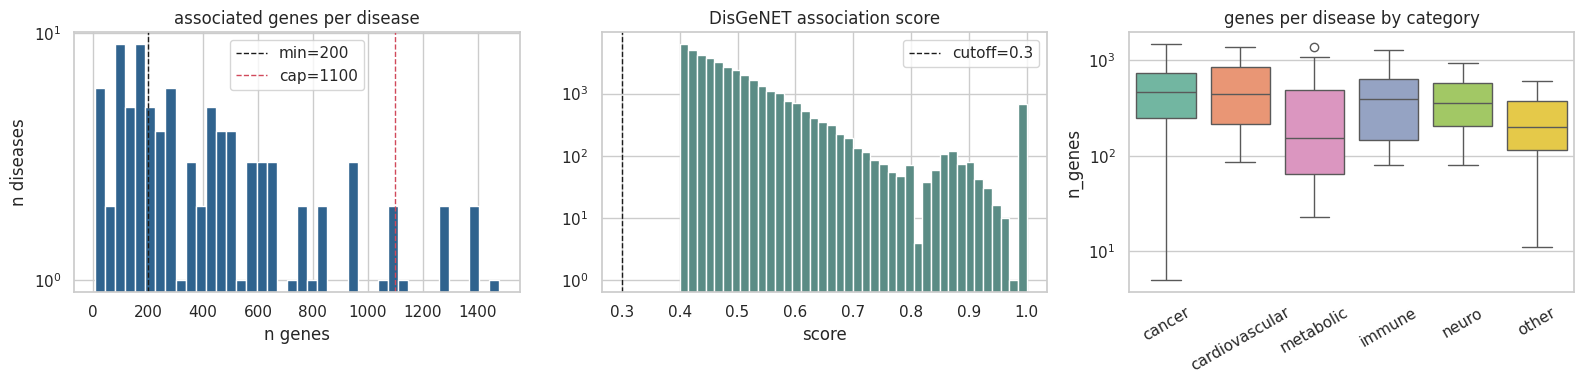

Largest and smallest disease gene sets:

                disease_label       category  n_genes  median_score
         Colorectal carcinoma         cancer     1479        0.4594
         Hypertensive disease cardiovascular     1392        0.4726
                      Obesity      metabolic     1370        0.4704
  Inflammatory bowel diseases         immune     1278        0.4828
                     Melanoma         cancer     1275        0.4702
Non-small cell lung carcinoma         cancer     1132        0.4612
     Hepatocellular carcinoma         cancer     1091        0.4586
     Type 2 diabetes mellitus      metabolic     1083        0.4692
              Hemochromatosis      metabolic       65        0.4500
      Obstructive sleep apnea          other       56        0.4482
                       Sepsis          other       35        0.4302
Familial hypercholesterolemia      metabolic       28        0.4668
              Phenylketonuria      metabolic       23        0.4282
       

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
CATEGORY_PALETTE = dict(zip(sorted(gdas["category"].unique()),
                            sns.color_palette("Set2", gdas["category"].nunique())))

per_disease = (
    gdas.groupby(["cui", "disease_label", "category"])
        .agg(n_genes=("gene_symbol", "nunique"),
             median_score=("score", "median"),
             max_score=("score", "max"))
        .reset_index()
        .sort_values("n_genes", ascending=False)
)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(per_disease["n_genes"], bins=40, color="#30638e")
ax[0].axvline(MIN_GENES_PER_DISEASE, color="k", ls="--", lw=1, label=f"min={MIN_GENES_PER_DISEASE}")
ax[0].axvline(MAX_GENES_PER_DISEASE, color="#d1495b", ls="--", lw=1, label=f"cap={MAX_GENES_PER_DISEASE}")
ax[0].set(title="associated genes per disease", xlabel="n genes", ylabel="n diseases")
ax[0].set_yscale("log"); ax[0].legend()

ax[1].hist(gdas["score"].dropna(), bins=40, color="#5b8c85")
ax[1].axvline(DISGENET_MIN_SCORE, color="k", ls="--", lw=1, label=f"cutoff={DISGENET_MIN_SCORE}")
ax[1].set(title="DisGeNET association score", xlabel="score"); ax[1].set_yscale("log"); ax[1].legend()

sns.boxplot(data=per_disease, x="category", y="n_genes", ax=ax[2],
            palette=CATEGORY_PALETTE, hue="category", legend=False)
ax[2].set_yscale("log"); ax[2].set(title="genes per disease by category", xlabel="")
ax[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print("Largest and smallest disease gene sets:\n")
print(pd.concat([per_disease.head(8), per_disease.tail(8)])
      [["disease_label", "category", "n_genes", "median_score"]].to_string(index=False))

In [19]:
# How much of the atlas survives each stringency? Chosen cutoff = DISGENET_MIN_SCORE (section 0).
rows = []
for label, cutoff in [("permissive", 0.0), ("medium", 0.30), ("stringent", 0.50)]:
    sub = gdas[gdas["score"] >= cutoff]
    counts = sub.groupby("cui")["gene_symbol"].nunique()
    usable = counts[counts >= MIN_GENES_PER_DISEASE]
    rows.append(dict(stringency=label, min_score=cutoff, associations=len(sub),
                     diseases=counts.size, usable_diseases=usable.size,
                     median_genes=int(counts.median()) if counts.size else 0,
                     max_genes=int(counts.max()) if counts.size else 0))
print(pd.DataFrame(rows).to_string(index=False))

stringency  min_score  associations  diseases  usable_diseases  median_genes  max_genes
permissive        0.0         39736        93               60           324       1479
    medium        0.3         39736        93               60           324       1479
 stringent        0.5         13166        92               23            95        538


## 4 — Gene filtering and identifier mapping

Three things happen here, in order:

1. **Protein-coding only** — required by construction: a node must have a protein sequence for its
   ESM-2 embedding and a STRING entry for its edges. `mygene` maps NCBI gene IDs → Ensembl gene ID +
   symbol + biotype in one query.
2. **Evidence cutoff** — `score >= DISGENET_MIN_SCORE`.
3. **Size cap** — the top `MAX_GENES_PER_DISEASE` genes by association score, so that graph size does
   not become the dominant axis of variation for the graph-level SAE.

Every step reports what it removed.

In [20]:
import mygene

gene_keys = (
    gdas[["gene_ncbi_id", "gene_symbol", "gene_ensembl"]]
    .drop_duplicates(subset=["gene_symbol"])
    .reset_index(drop=True)
)
has_ncbi = gene_keys["gene_ncbi_id"].notna().mean()
print(f"{len(gene_keys):,} distinct genes | NCBI ID present for {has_ncbi:.0%}")

# Query by NCBI gene ID when available (unambiguous), otherwise by symbol.
mg = mygene.MyGeneInfo()
use_ncbi = has_ncbi > 0.5
query_ids = (gene_keys["gene_ncbi_id"] if use_ncbi else gene_keys["gene_symbol"]).dropna().astype(str)
info = mg.querymany(
    query_ids.tolist(),
    scopes="entrezgene" if use_ncbi else "symbol",
    fields="symbol,ensembl.gene,type_of_gene",
    species="human", as_dataframe=True, verbose=False,
)
info = info[~info.index.duplicated(keep="first")]


def _first_ensembl(row):
    # mygene returns either 'ensembl.gene' (1:1) or 'ensembl' (a list of dicts, 1:many)
    val = row.get("ensembl.gene")
    if isinstance(val, str):
        return val
    ens = row.get("ensembl")
    if isinstance(ens, list) and ens:
        return ens[0].get("gene")
    if isinstance(ens, dict):
        return ens.get("gene")
    return None


info["ensembl_id"] = info.apply(_first_ensembl, axis=1)
info["biotype"] = info.get("type_of_gene", pd.Series(index=info.index, dtype=object))

gene_map = gene_keys.copy()
gene_map["_key"] = (gene_map["gene_ncbi_id"] if use_ncbi else gene_map["gene_symbol"]).astype(str)
gene_map = gene_map.join(info[["symbol", "ensembl_id", "biotype"]], on="_key")
gene_map["symbol"] = gene_map["symbol"].fillna(gene_map["gene_symbol"])

n_before = len(gene_map)
gene_map = gene_map[gene_map["biotype"].astype(str).str.contains("protein", case=False, na=False)]
gene_map = gene_map[gene_map["ensembl_id"].notna()].drop_duplicates(subset=["gene_symbol"])
print(f"Protein-coding with an Ensembl gene ID: {n_before:,} → {len(gene_map):,} genes")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


6,858 distinct genes | NCBI ID present for 0%
Protein-coding with an Ensembl gene ID: 6,858 → 6,764 genes


In [21]:
# Apply the evidence cutoff + size cap, then drop diseases that end up too small.
flt = gdas[gdas["score"] >= DISGENET_MIN_SCORE].copy()
print(f"score >= {DISGENET_MIN_SCORE}: {len(gdas):,} → {len(flt):,} associations")

flt = flt.merge(gene_map[["gene_symbol", "symbol", "ensembl_id"]], on="gene_symbol", how="inner")
print(f"protein-coding + mappable:   → {len(flt):,} associations")

flt = (flt.sort_values("score", ascending=False)
          .drop_duplicates(subset=["cui", "ensembl_id"])
          .groupby("cui", group_keys=False)
          .head(MAX_GENES_PER_DISEASE))
print(f"top-{MAX_GENES_PER_DISEASE} per disease:    → {len(flt):,} associations")

sizes = flt.groupby("cui")["ensembl_id"].nunique()
too_small = sizes[sizes < MIN_GENES_PER_DISEASE]
flt = flt[~flt["cui"].isin(too_small.index)]
if len(too_small):
    dropped = (per_disease.set_index("cui").loc[too_small.index, "disease_label"]
               + " (" + too_small.astype(str) + ")")
    print(f"\nDropped {len(too_small)} diseases with < {MIN_GENES_PER_DISEASE} usable genes:")
    print("   " + "; ".join(dropped.tolist()))

print(f"\nSeed sets ready: {flt['cui'].nunique()} diseases, "
      f"{flt['ensembl_id'].nunique():,} distinct genes, {len(flt):,} associations")
print(flt.groupby("cui")["ensembl_id"].nunique().describe().round(1).to_string())

score >= 0.3: 39,736 → 39,736 associations
protein-coding + mappable:   → 39,373 associations
top-1100 per disease:    → 38,116 associations

Dropped 33 diseases with < 200 usable genes:
   Sickle cell anemia (91); Hypertrophic cardiomyopathy (163); Celiac disease (182); Charcot-Marie-Tooth disease (155); Type 1 diabetes mellitus (168); Duchenne muscular dystrophy (108); Gout (151); Graves disease (101); Hemochromatosis (65); Hemophilia A (11); Familial hypercholesterolemia (28); Long QT syndrome (122); Marfan syndrome (20); Medulloblastoma (168); Spinal muscular atrophy (79); Nephrotic syndrome (140); Phenylketonuria (23); Polycystic ovary syndrome (161); Pre-eclampsia (196); Ankylosing spondylitis (120); Vitiligo (127); Autosomal dominant polycystic kidney disease (138); Small cell lung carcinoma (5); Migraine disorders (179); Esophageal carcinoma (86); Abdominal aortic aneurysm (87); Sepsis (35); Frontotemporal dementia (186); Endometrial carcinoma (96); Obstructive sleep apnea (54)

## 5 — The STRING backbone

One global interaction network, downloaded once (~160 MB, cached in `data/disgenet/string/`), from
which every disease graph is cut. We use the **detailed** links file rather than the REST API for two
reasons: it is reproducible (a fixed release), and it keeps the individual evidence channels
(`experimental`, `database`, `coexpression`, `textmining`, …) that the edge-level SAE may want later.

Edges are kept at `combined_score >= 700` (STRING's "high confidence"). The weight stored on the edge
is $w_{ij} = s_{ij}/1000 \in (0, 1]$ — never a binary adjacency, so the edge SAE can distinguish
"these proteins interact" from "these proteins interact with strong experimental support".

In [22]:
STRING_FILES = {
    "links":   f"protein.links.detailed.v{STRING_VERSION}/{SPECIES}.protein.links.detailed.v{STRING_VERSION}.txt.gz",
    "info":    f"protein.info.v{STRING_VERSION}/{SPECIES}.protein.info.v{STRING_VERSION}.txt.gz",
    "aliases": f"protein.aliases.v{STRING_VERSION}/{SPECIES}.protein.aliases.v{STRING_VERSION}.txt.gz",
}
STRING_BASE_URL = "https://stringdb-downloads.org/download"


def fetch_string_file(kind):
    remote = STRING_FILES[kind]
    return download_file(f"{STRING_BASE_URL}/{remote}", STRING_DIR / Path(remote).name)


links_path   = fetch_string_file("links")
info_path    = fetch_string_file("info")
aliases_path = fetch_string_file("aliases")

(cached) 9606.protein.links.detailed.v12.0.txt.gz  140 MB
(cached) 9606.protein.info.v12.0.txt.gz  2 MB
(cached) 9606.protein.aliases.v12.0.txt.gz  20 MB


In [23]:
# ── Identifier bridges: Ensembl gene ID / symbol → STRING protein ID ─────────
aliases = pd.read_csv(aliases_path, sep="\t", names=["string_id", "alias", "source"],
                      skiprows=1, dtype=str)
info = pd.read_csv(info_path, sep="\t", dtype=str).rename(
    columns={"#string_protein_id": "string_id"})

# Primary bridge: STRING's own Ensembl_gene alias (ENSG → ENSP), one row per protein.
ensg = (aliases[aliases["source"] == "Ensembl_gene"]
        .drop_duplicates(subset="alias")
        .set_index("alias")["string_id"])
# Secondary bridge: preferred name (HGNC symbol) for genes whose ENSG is not listed.
sym = info.drop_duplicates(subset="preferred_name").set_index("preferred_name")["string_id"]

print(f"STRING v{STRING_VERSION}: {info['string_id'].nunique():,} human proteins | "
      f"{len(ensg):,} Ensembl-gene aliases | {len(sym):,} preferred names")

gene_map["string_id"] = gene_map["ensembl_id"].map(ensg)
fallback = gene_map["string_id"].isna()
gene_map.loc[fallback, "string_id"] = gene_map.loc[fallback, "symbol"].map(sym)

mapped = gene_map["string_id"].notna()
print(f"\nGene → STRING protein: {mapped.sum():,}/{len(gene_map):,} ({mapped.mean():.1%}) "
      f"[{(~fallback & mapped).sum():,} via Ensembl, {(fallback & mapped).sum():,} via symbol]")
gene_map = gene_map[mapped].copy()

# A STRING protein may be reachable from more than one gene ID; keep one gene per protein.
gene_map = gene_map.drop_duplicates(subset="string_id")
gene_map.to_csv(GENEMAP_FILE, sep="\t", index=False)
gene_map[["gene_symbol", "symbol", "ensembl_id", "string_id"]].head()

STRING v12.0: 19,699 human proteins | 19,699 Ensembl-gene aliases | 19,699 preferred names

Gene → STRING protein: 6,764/6,764 (100.0%) [6,474 via Ensembl, 290 via symbol]


,gene_symbol,symbol,ensembl_id,string_id
0,FKBP4,FKBP4,ENSG00000004478,9606.ENSP00000001008
1,FUCA2,FUCA2,ENSG00000001036,9606.ENSP00000002165
2,CFTR,CFTR,ENSG00000001626,9606.ENSP00000003084
3,USP28,USP28,ENSG00000048028,9606.ENSP00000003302
4,HSPB6,HSPB6,ENSG00000004776,9606.ENSP00000004982


In [24]:
# Per-disease mapping QC — which diseases lose the most genes on the way to STRING?
seeds = flt.merge(gene_map[["ensembl_id", "string_id", "symbol"]], on="ensembl_id", how="left")
mapping_qc = (
    seeds.groupby(["cui", "disease_label", "category"])
         .agg(n_genes=("ensembl_id", "nunique"),
              n_mapped=("string_id", lambda s: s.notna().sum()))
         .reset_index()
)
mapping_qc["frac_mapped"] = mapping_qc["n_mapped"] / mapping_qc["n_genes"]
print(f"Median mapping rate across diseases: {mapping_qc['frac_mapped'].median():.1%}")
print("\nWorst-mapped diseases:")
print(mapping_qc.nsmallest(5, "frac_mapped")[
    ["disease_label", "n_genes", "n_mapped", "frac_mapped"]].to_string(index=False))

# Drop unmapped genes and collapse duplicate (disease, protein) rows, keeping the best evidence.
seeds = (seeds[seeds["string_id"].notna()]
         .sort_values("score", ascending=False)
         .drop_duplicates(subset=["cui", "string_id"])
         .reset_index(drop=True))
print(f"\nSeed table: {len(seeds):,} (disease, protein) pairs | "
      f"{seeds['string_id'].nunique():,} distinct proteins")

Median mapping rate across diseases: 100.0%

Worst-mapped diseases:
                disease_label  n_genes  n_mapped  frac_mapped
          Alzheimer's disease      923       923          1.0
Amyotrophic lateral sclerosis      415       415          1.0
         Rheumatoid arthritis      933       933          1.0
                       Asthma      646       646          1.0
              Atherosclerosis      814       814          1.0

Seed table: 34,520 (disease, protein) pairs | 6,217 distinct proteins


In [25]:
# ── Load the interaction network, restricted to the atlas' protein universe ──
protein_universe = set(seeds["string_id"].unique())
USE_COLS = ["protein1", "protein2", "experimental", "database", "combined_score"]

kept = []
reader = pd.read_csv(links_path, sep=" ", usecols=USE_COLS, chunksize=2_000_000)
for chunk in tqdm(reader, desc="Scanning STRING links"):
    chunk = chunk[chunk["combined_score"] >= STRING_MIN_SCORE]
    chunk = chunk[chunk["protein1"].isin(protein_universe) & chunk["protein2"].isin(protein_universe)]
    kept.append(chunk[chunk["protein1"] < chunk["protein2"]])   # each pair is listed twice; keep one

links = pd.concat(kept, ignore_index=True)
del kept
links["weight"] = links["combined_score"] / 1000.0
links["physical"] = (links[PHYSICAL_CHANNELS] > 0).any(axis=1)

print(f"\n{len(links):,} unique interactions at combined_score >= {STRING_MIN_SCORE} "
      f"among {len(protein_universe):,} proteins")
print(f"  experimental/database supported: {links['physical'].mean():.1%}")
print(f"  weight: median {links['weight'].median():.3f}, mean {links['weight'].mean():.3f}")

Scanning STRING links: 0it [00:00, ?it/s]


77,475 unique interactions at combined_score >= 700 among 6,217 proteins
  experimental/database supported: 72.7%
  weight: median 0.846, mean 0.851


## 6 — ESM-2 node features

Protein identity is supplied by ESM-2, exactly as in the IBD and T2D tutorials: the embeddings are
computed **once** for the whole protein universe and every disease graph then slices the rows it
needs. This is what makes variable node sets defensible — two graphs sharing no genes are still
comparable, because their nodes live in the same protein representation space.

Run once (GPU recommended), from the repository root:

```bash
python3 docs/scripts/get_esm_embeddings.py \
    --gene-list docs/tutorial/data/disgenet/ensembl_ids_diseases.txt \
    --out       docs/tutorial/data/disgenet/esm_embeddings_diseases.pt \
    --species   human \
    --model     facebook/esm2_t33_650M_UR50D
```

If the file is absent the notebook still builds the atlas, using the DisGeNET evidence vector alone as
node features, and says so — Part 2 (GCN with an ESM-reconstruction objective) requires the real
embeddings.

In [29]:
from gea.utils import compress_embeddings_pca, load_esm_embeddings

# Global protein table — this row order defines node indices everywhere downstream.
proteins = (gene_map[gene_map["string_id"].isin(protein_universe)]
            [["string_id", "ensembl_id", "symbol"]]
            .drop_duplicates(subset="string_id")
            .sort_values("string_id")
            .reset_index(drop=True))
p_index = pd.Series(proteins.index.values, index=proteins["string_id"])
print(f"Protein universe: {len(proteins):,} proteins")

ENSEMBL_FILE.write_text("\n".join(proteins["ensembl_id"].tolist()))
print(f"Gene list for the ESM script → {ENSEMBL_FILE}")

esm_matrix, esm_available, esm_present = None, False, set()
if ESM_FILE.exists():
    try:    # metadata-only read: we only need the key set for the coverage QC
        esm_present = set(torch.load(ESM_FILE, weights_only=False, map_location="meta"))
    except Exception:                                   # noqa: BLE001
        esm_present = set(torch.load(ESM_FILE, weights_only=False))
    esm_matrix = load_esm_embeddings(str(ESM_FILE), proteins["ensembl_id"].tolist(), aggregation="mean")
    esm_matrix = compress_embeddings_pca(esm_matrix, n_components=ESM_PCA_DIM, whiten=True)
    esm_available = True
    print(f"ESM-2 node features: {tuple(esm_matrix.shape)}")
else:
    print(f"!! {ESM_FILE} not found — building graphs with association-evidence features only.\n"
          f"   Run the command above, then re-run this cell and section 7.")

Protein universe: 6,217 proteins
Gene list for the ESM script → data/disgenet/ensembl_ids_diseases.txt


Loading ESM-2 embeddings: 100%|██████████| 6217/6217 [00:00<00:00, 23216.90it/s]


Found ESM-2 embeddings for 6216/6217 genes.
PCA: 1280→256 dims, 91.7% variance retained.
ESM-2 node features: (6217, 256)


## 7 — Graph construction

For each disease $d$:

$$V_d = \{\text{mapped protein-coding DisGeNET genes}\},\qquad
  E_d = \{(u,v) \in E_{\text{STRING}} : u,v \in V_d\}$$

i.e. the **induced subgraph** — no 1-hop expansion in this baseline. Isolated nodes (no
high-confidence partner inside the disease gene set) are dropped by default, since they contribute no
message passing, and the fraction dropped is recorded per disease.

Each `Data` object follows the layout the GEA models already expect:

| field | content |
|---|---|
| `x` | `[disease-association score ‖ ESM-2 PCA]` — same slot layout as `[expression ‖ ESM-2]` in the LIONESS graphs, so `GNNModel(input_proj_dim=…)` works unchanged |
| `node_evidence` | association evidence per node: `score, ei, dsi, dpi, log1p(n_pmids)` — DisGeNET fills all five, DISEASES only `score` (the rest are 0) |
| `edge_index`, `edge_attr` | both directions; weight $= s_{ij}/1000$ |
| `edge_type` | `0` = experimental/database supported, `1` = inferred channels only (the two R-GCN relations) |
| `y`, `y_dis` | disease **category** and disease identity, integer-encoded |
| `gene_symbols`, `ensembl_ids`, `string_ids` | node identity, for enrichment and plotting |

In [30]:
from torch_geometric.data import Data

# Edge arrays in global protein-index space — membership tests then become O(1) per edge.
E1 = links["protein1"].map(p_index).to_numpy()
E2 = links["protein2"].map(p_index).to_numpy()
EW = links["weight"].to_numpy(dtype=np.float32)
EP = links["physical"].to_numpy()

EVIDENCE_COLS = ["score", "ei", "dsi", "dpi", "log1p_pmids"]
seeds["log1p_pmids"] = np.log1p(pd.to_numeric(seeds.get("n_pmids"), errors="coerce").fillna(0))
for col in ["ei", "dsi", "dpi"]:
    seeds[col] = pd.to_numeric(seeds[col], errors="coerce").fillna(0.0)

categories = sorted(seeds["category"].unique())
cat_map = {c: i for i, c in enumerate(categories)}
disease_names = sorted(seeds["disease_label"].unique())
dis_map = {d: i for i, d in enumerate(disease_names)}


def build_disease_graph(sub):
    # sub: the seed rows of one disease, one row per (disease, protein)
    nodes = np.sort(sub["p_idx"].to_numpy())
    member = np.zeros(len(proteins), dtype=bool)
    member[nodes] = True

    sel = member[E1] & member[E2]
    a, b, w, phys = E1[sel], E2[sel], EW[sel], EP[sel]

    if DROP_ISOLATED_NODES:
        connected = np.unique(np.concatenate([a, b])) if len(a) else np.array([], dtype=int)
        nodes = connected
    if KEEP_LARGEST_CC and len(nodes):
        import scipy.sparse as sp
        from scipy.sparse.csgraph import connected_components
        loc = -np.ones(len(proteins), dtype=np.int64); loc[nodes] = np.arange(len(nodes))
        adj = sp.coo_matrix((np.ones(len(a)), (loc[a], loc[b])), shape=(len(nodes),) * 2)
        n_cc, lab = connected_components(adj, directed=False)
        keep = lab == np.bincount(lab).argmax()
        nodes = nodes[keep]
        member = np.zeros(len(proteins), dtype=bool); member[nodes] = True
        sel2 = member[a] & member[b]
        a, b, w, phys = a[sel2], b[sel2], w[sel2], phys[sel2]

    if len(nodes) < MIN_NODES or len(a) < MIN_EDGES:
        return None, dict(n_nodes=len(nodes), n_edges=len(a), dropped=True)

    local = -np.ones(len(proteins), dtype=np.int64)
    local[nodes] = np.arange(len(nodes))
    ia, ib = local[a], local[b]

    # Node-aligned evidence, in the same order as `nodes`
    ev = (sub.set_index("p_idx").loc[nodes, EVIDENCE_COLS]
             .astype(np.float32).to_numpy())
    evidence = torch.from_numpy(ev)
    x = torch.cat([evidence[:, :1], esm_matrix[nodes]], dim=1) if esm_available else evidence

    edge_index = torch.tensor(np.stack([np.concatenate([ia, ib]),
                                        np.concatenate([ib, ia])]), dtype=torch.long)
    edge_attr = torch.tensor(np.concatenate([w, w]), dtype=torch.float32)
    edge_type = torch.tensor(np.concatenate([~phys, ~phys]).astype(np.int64), dtype=torch.long)

    row = sub.iloc[0]
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    data.edge_type = edge_type
    data.node_evidence = evidence
    data.y = torch.tensor(cat_map[row["category"]], dtype=torch.long)
    data.y_dis = torch.tensor(dis_map[row["disease_label"]], dtype=torch.long)
    data.disease = row["disease_label"]
    data.category = row["category"]
    data.cui = row["cui"]
    data.sample_name = row["disease_label"]          # GEA annotation helpers key on this
    data.gene_symbols = proteins.loc[nodes, "symbol"].tolist()
    data.ensembl_ids = proteins.loc[nodes, "ensembl_id"].tolist()
    data.string_ids = proteins.loc[nodes, "string_id"].tolist()
    data.n_seed_genes = int(len(sub))

    stats = dict(n_nodes=len(nodes), n_edges=len(a), dropped=False)
    return data, stats

In [31]:
seeds["p_idx"] = seeds["string_id"].map(p_index).astype(int)

graphs, build_log = [], []
for (cui, label, category), sub in tqdm(seeds.groupby(["cui", "disease_label", "category"]),
                                        desc="Building disease graphs"):
    data, stats = build_disease_graph(sub)
    isolated = 1 - stats["n_nodes"] / sub["p_idx"].nunique()
    build_log.append(dict(cui=cui, disease=label, category=category,
                          n_seed_genes=sub["p_idx"].nunique(), frac_isolated=isolated, **stats))
    if data is not None:
        graphs.append(data)

build_log = pd.DataFrame(build_log)
dropped = build_log[build_log["dropped"]]
print(f"\nBuilt {len(graphs)} disease graphs "
      f"({len(dropped)} dropped for < {MIN_NODES} nodes / < {MIN_EDGES} edges)")
if len(dropped):
    print(dropped[["disease", "n_seed_genes", "n_nodes", "n_edges"]].to_string(index=False))
print(f"\nNode feature dim: {graphs[0].x.shape[1]} "
      f"({'1 evidence score + ' + str(ESM_PCA_DIM) + ' ESM-2 PCA' if esm_available else 'association evidence only'})")

Building disease graphs:   0%|          | 0/60 [00:00<?, ?it/s]


Built 60 disease graphs (0 dropped for < 15 nodes / < 20 edges)

Node feature dim: 257 (1 evidence score + 256 ESM-2 PCA)


## 8 — Graph QC

The question this section answers is *are these graphs comparable at all?* Anything that is dominated
by one huge hairball, or that shatters into singletons, will confuse the graph-level SAE far more than
any modelling choice made later.

In [32]:
import networkx as nx


def to_networkx(data):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    ei = data.edge_index.numpy()
    w = data.edge_attr.numpy()
    half = ei.shape[1] // 2                              # both directions are stored; use one
    g.add_weighted_edges_from(zip(ei[0, :half], ei[1, :half], w[:half]))
    return g


rows = []
for data in tqdm(graphs, desc="Graph statistics"):
    g = to_networkx(data)
    deg = np.array([d for _, d in g.degree()])
    comps = list(nx.connected_components(g))
    lcc = max(comps, key=len)
    communities = nx.community.louvain_communities(g, weight="weight", seed=0)
    esm_cov = (np.mean([e in esm_present for e in data.ensembl_ids]) if esm_present else np.nan)
    rows.append(dict(
        disease=data.disease, category=data.category, cui=data.cui,
        n_seed_genes=data.n_seed_genes, n_nodes=g.number_of_nodes(), n_edges=g.number_of_edges(),
        density=nx.density(g), deg_mean=deg.mean(), deg_median=np.median(deg), deg_max=deg.max(),
        n_components=len(comps), lcc_frac=len(lcc) / g.number_of_nodes(),
        clustering=nx.average_clustering(g, weight="weight"),
        assortativity=nx.degree_assortativity_coefficient(g),
        modularity=nx.community.modularity(g, communities, weight="weight"),
        frac_physical=float((data.edge_type == 0).float().mean()),
        mean_weight=float(data.edge_attr.mean()), esm_coverage=esm_cov,
    ))

stats = pd.DataFrame(rows).sort_values("n_nodes", ascending=False).reset_index(drop=True)
stats.to_csv(STATS_FILE, index=False)
print(stats.describe().loc[["mean", "50%", "min", "max"],
      ["n_nodes", "n_edges", "density", "deg_mean", "n_components", "lcc_frac",
       "clustering", "modularity"]].round(3).to_string())

Graph statistics:   0%|          | 0/60 [00:00<?, ?it/s]

       n_nodes    n_edges  density  deg_mean  n_components  lcc_frac  clustering  modularity
mean   547.317   8432.983    0.064    28.877         2.667     0.990       0.410       0.416
50%    464.000   6997.500    0.058    29.698         2.000     0.995       0.408       0.416
min    181.000   1142.000    0.023    12.619         1.000     0.943       0.345       0.283
max   1096.000  21306.000    0.144    39.915         9.000     1.000       0.522       0.550


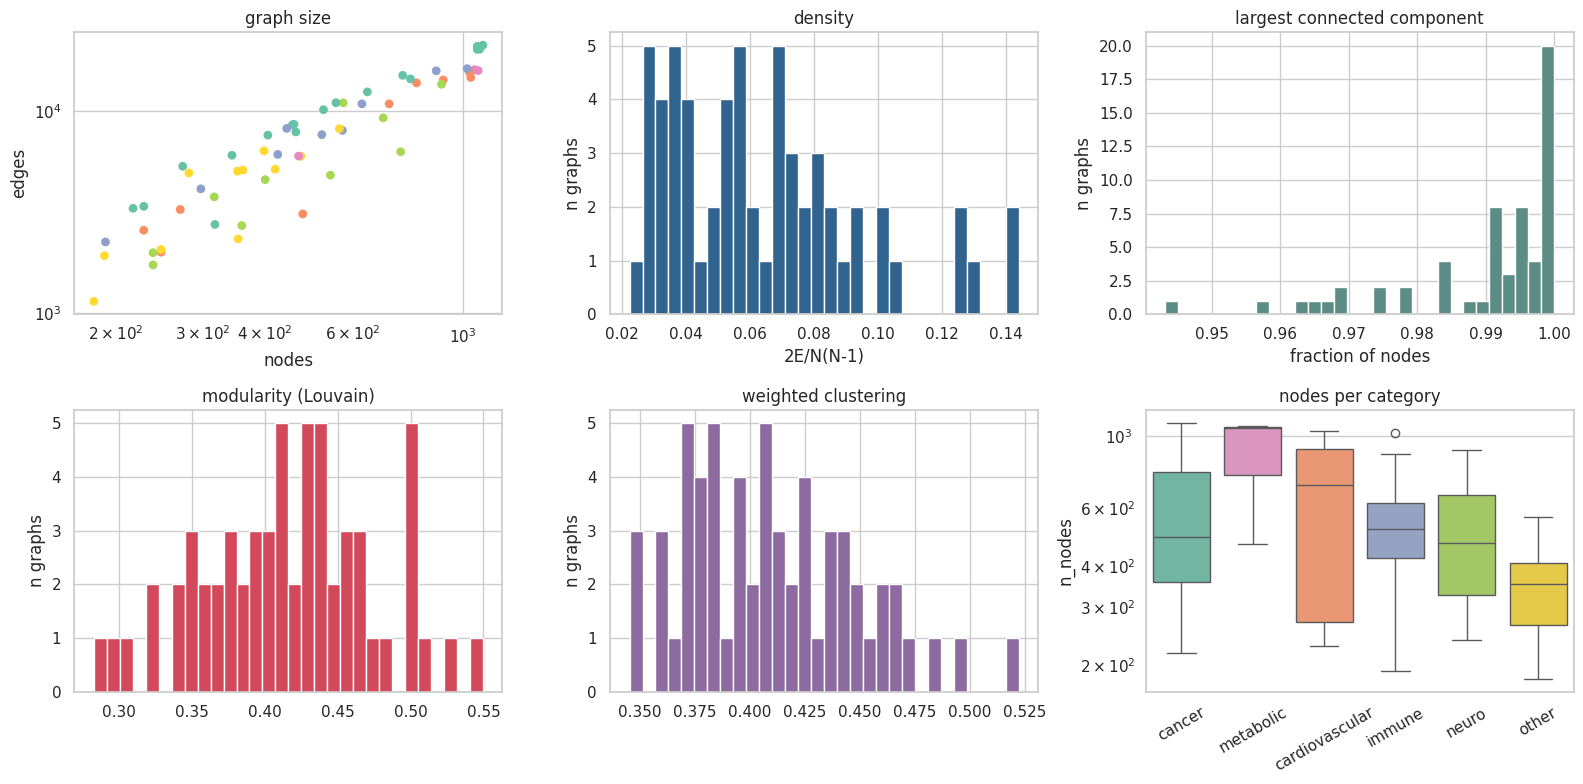

Flagged 0 graphs (small, fragmented, or near-complete):
   none

Largest / smallest graphs:
                      disease       category  n_nodes  n_edges  density  modularity
         Colorectal carcinoma         cancer     1096    21306 0.035506    0.459235
Non-small cell lung carcinoma         cancer     1080    20354 0.034933    0.467727
                      Obesity      metabolic     1072    15935 0.027759    0.484053
                     Melanoma         cancer     1068    20313 0.035651    0.439930
     Hepatocellular carcinoma         cancer     1068    21024 0.036899    0.463469
       Pulmonary hypertension cardiovascular      228     2573 0.099428    0.344878
            Ovarian carcinoma         cancer      217     3307 0.141108    0.325676
         Systemic scleroderma         immune      191     2251 0.124056    0.282555
              Cystic fibrosis          other      190     1926 0.107268    0.344257
         Retinitis pigmentosa          other      181     1142 0.070

In [33]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax = ax.ravel()
ax[0].scatter(stats["n_nodes"], stats["n_edges"], s=28,
              c=[CATEGORY_PALETTE[c] for c in stats["category"]])
ax[0].set(xscale="log", yscale="log", xlabel="nodes", ylabel="edges", title="graph size")
ax[1].hist(stats["density"], bins=30, color="#30638e"); ax[1].set(title="density", xlabel="2E/N(N-1)")
ax[2].hist(stats["lcc_frac"], bins=30, color="#5b8c85")
ax[2].set(title="largest connected component", xlabel="fraction of nodes")
ax[3].hist(stats["modularity"], bins=30, color="#d1495b"); ax[3].set(title="modularity (Louvain)")
ax[4].hist(stats["clustering"], bins=30, color="#8d6a9f"); ax[4].set(title="weighted clustering")
sns.boxplot(data=stats, x="category", y="n_nodes", ax=ax[5], palette=CATEGORY_PALETTE,
            hue="category", legend=False)
ax[5].set(yscale="log", title="nodes per category", xlabel="")
ax[5].tick_params(axis="x", rotation=30)
for a in ax:
    a.set_ylabel(a.get_ylabel() or "n graphs")
plt.tight_layout(); plt.show()

flags = stats[(stats["n_nodes"] < 40) | (stats["lcc_frac"] < 0.5) | (stats["density"] > 0.4)]
print(f"Flagged {len(flags)} graphs (small, fragmented, or near-complete):")
print(flags[["disease", "category", "n_nodes", "n_edges", "density", "lcc_frac"]].to_string(index=False)
      if len(flags) else "   none")
print("\nLargest / smallest graphs:")
print(pd.concat([stats.head(5), stats.tail(5)])
      [["disease", "category", "n_nodes", "n_edges", "density", "modularity"]].to_string(index=False))

## 9 — A look at individual disease networks

Sanity check, not analysis: do the graphs look like disease modules — a connected core of well-known
genes plus periphery — or like noise? Only the largest connected component is drawn; node size is
degree, colour is the DisGeNET association score, and the ten highest-degree genes are labelled.

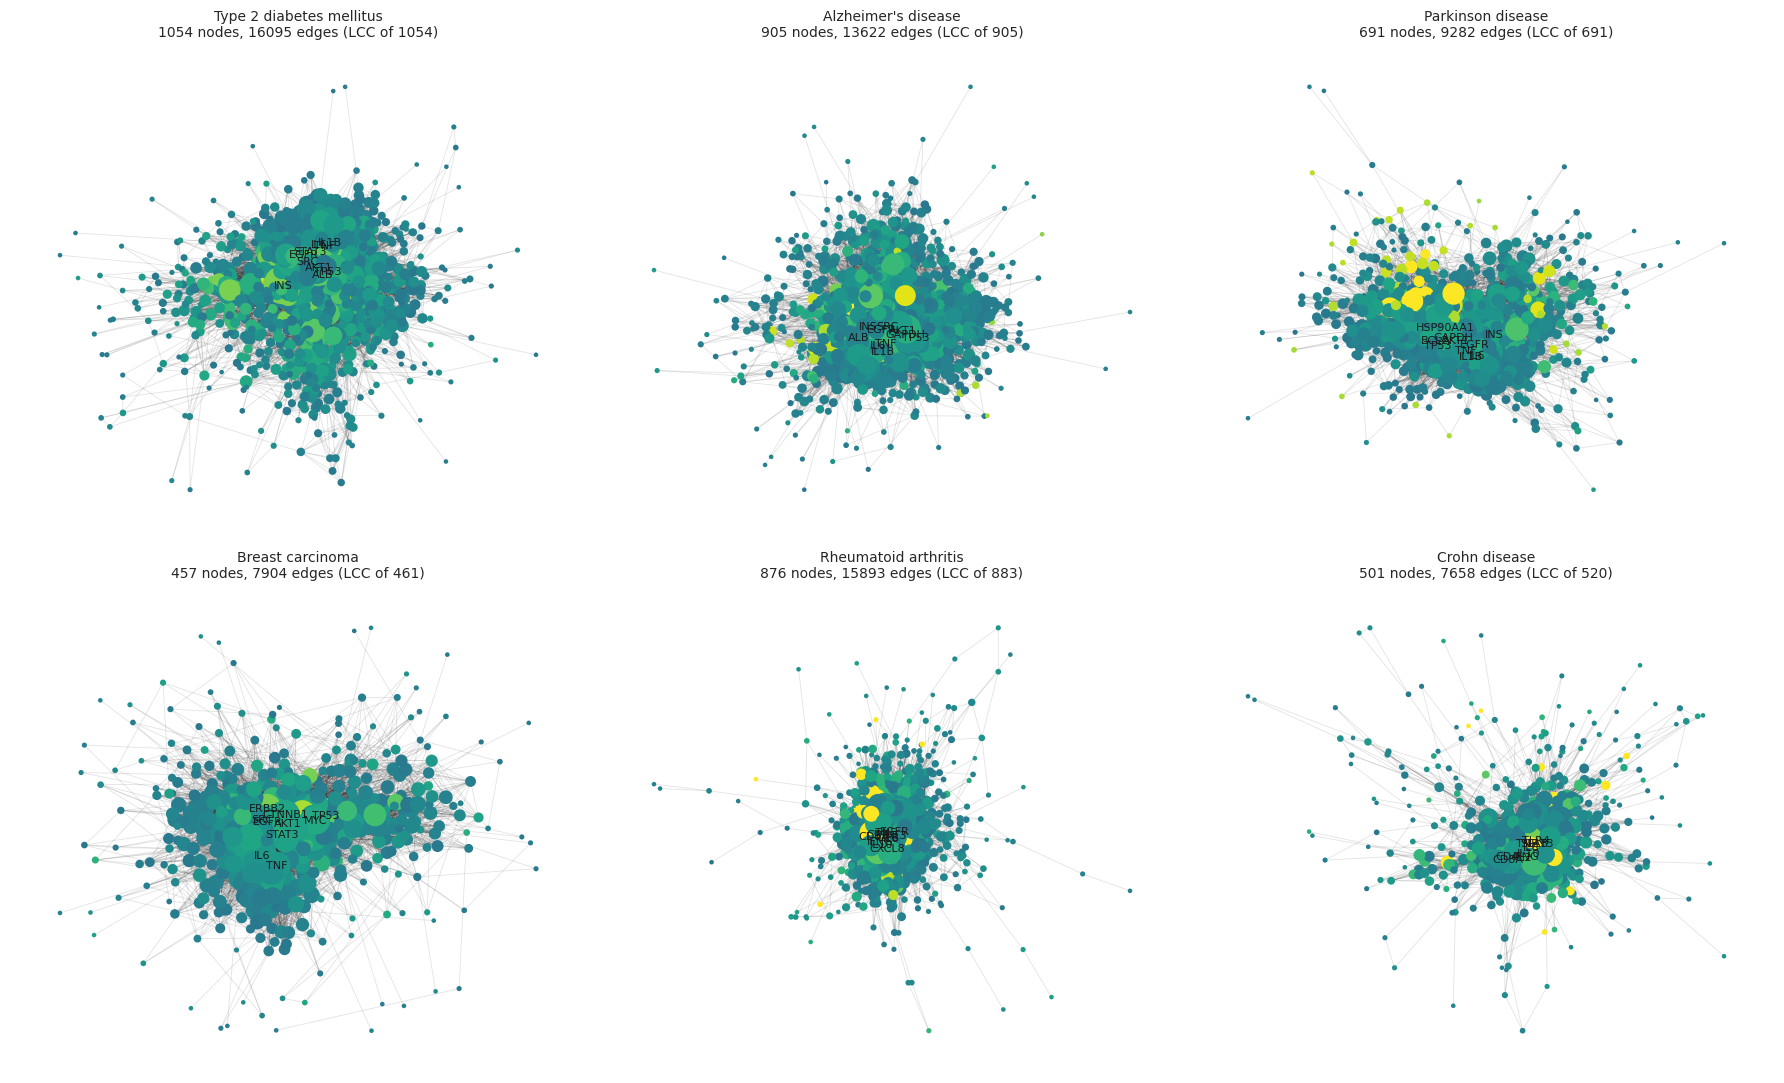

In [34]:
SHOWCASE = ["Type 2 diabetes mellitus", "Alzheimer's disease", "Parkinson disease",
            "Breast carcinoma", "Rheumatoid arthritis", "Crohn disease"]
by_name = {g.disease: g for g in graphs}
showcase = [by_name[d] for d in SHOWCASE if d in by_name][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for axis, data in zip(axes.ravel(), showcase):
    g = to_networkx(data)
    lcc = g.subgraph(max(nx.connected_components(g), key=len))
    pos = nx.spring_layout(lcc, weight="weight", seed=42, k=0.35)
    deg = dict(lcc.degree())
    score = data.node_evidence[:, 0].numpy()
    nx.draw_networkx_edges(lcc, pos, ax=axis, alpha=0.12, width=0.6)
    nx.draw_networkx_nodes(lcc, pos, ax=axis, node_size=[8 + 3 * deg[n] for n in lcc],
                           node_color=[score[n] for n in lcc], cmap="viridis", vmin=0, vmax=1,
                           linewidths=0)
    hubs = sorted(lcc, key=lambda n: deg[n], reverse=True)[:10]
    nx.draw_networkx_labels(lcc, pos, ax=axis, font_size=8,
                            labels={n: data.gene_symbols[n] for n in hubs})
    axis.set_title(f"{data.disease}\n{lcc.number_of_nodes()} nodes, {lcc.number_of_edges()} edges "
                   f"(LCC of {g.number_of_nodes()})", fontsize=10)
    axis.axis("off")
for axis in axes.ravel()[len(showcase):]:
    axis.axis("off")
plt.tight_layout(); plt.show()

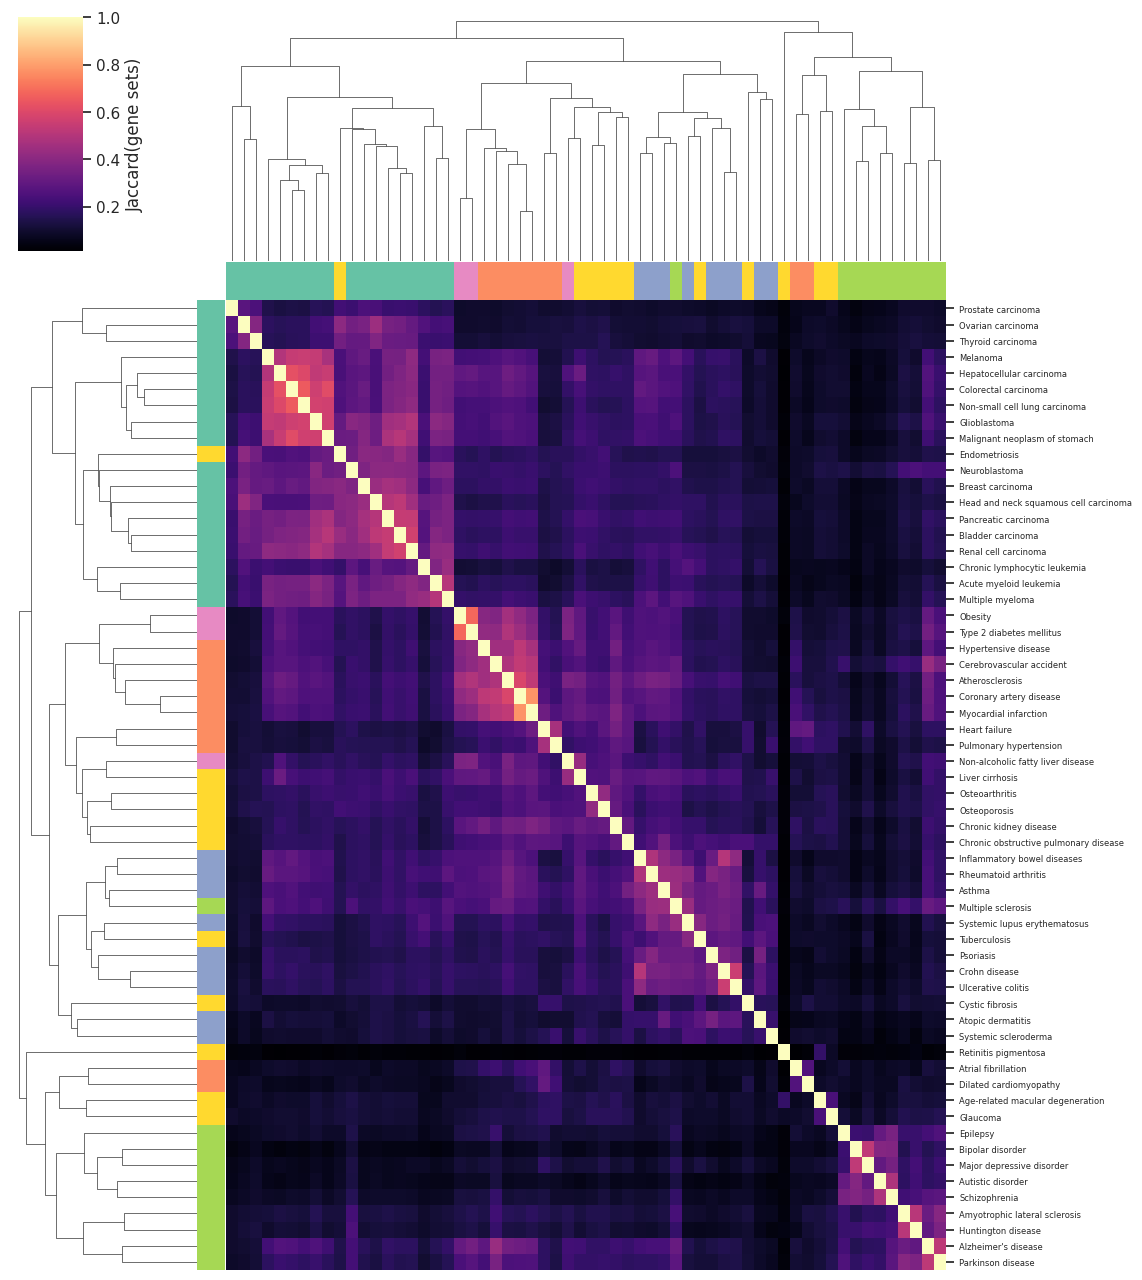

Pairwise gene-set overlap: median 0.157, 90th pct 0.321, max 0.777


In [35]:
# Gene-overlap baseline (Jaccard) — the first of the disease-similarity baselines the plan calls for,
# and the one to keep in mind when a graph-level SAE feature later groups a set of diseases together.
names = [g.disease for g in graphs]
sets = [set(g.string_ids) for g in graphs]
J = np.zeros((len(sets), len(sets)), dtype=np.float32)
for i, si in enumerate(sets):
    for j, sj in enumerate(sets):
        J[i, j] = len(si & sj) / len(si | sj)

order = np.argsort([f"{g.category}|{g.disease}" for g in graphs])
cat_colors = [CATEGORY_PALETTE[graphs[i].category] for i in order]
cg = sns.clustermap(pd.DataFrame(J[np.ix_(order, order)],
                                 index=[names[i] for i in order], columns=[names[i] for i in order]),
                    row_colors=cat_colors, col_colors=cat_colors, cmap="magma",
                    row_cluster=True, col_cluster=True, figsize=(13, 13),
                    xticklabels=False, yticklabels=1, cbar_kws=dict(label="Jaccard(gene sets)"))
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_yticklabels(), fontsize=6)
plt.show()

iu = np.triu_indices(len(sets), k=1)
print(f"Pairwise gene-set overlap: median {np.median(J[iu]):.3f}, "
      f"90th pct {np.quantile(J[iu], 0.9):.3f}, max {J[iu].max():.3f}")

## 10 — Export

The atlas is saved in the same format as `t2d_graphs.pt` / `ibd_graphs.pt`, so Part 2 can load it with
`torch.load(...)` and hand it straight to a loader.

In [36]:
torch.save(graphs, GRAPHS_FILE)
LABELS_FILE.write_text(json.dumps(
    dict(category_to_idx=cat_map, disease_to_idx=dis_map,
         esm_available=bool(esm_available), esm_pca_dim=ESM_PCA_DIM if esm_available else None,
         disgenet_source=DISGENET_SOURCE, disgenet_min_score=DISGENET_MIN_SCORE,
         string_version=STRING_VERSION, string_min_score=STRING_MIN_SCORE,
         max_genes_per_disease=MAX_GENES_PER_DISEASE, drop_isolated=DROP_ISOLATED_NODES,
         keep_largest_cc=KEEP_LARGEST_CC), indent=2))

print(f"{len(graphs)} graphs → {GRAPHS_FILE}")
print(f"per-graph statistics → {STATS_FILE}")
print(f"label maps + build parameters → {LABELS_FILE}\n")
print(f"nodes  : {stats['n_nodes'].min()}–{stats['n_nodes'].max()} (median {stats['n_nodes'].median():.0f})")
print(f"edges  : {stats['n_edges'].min()}–{stats['n_edges'].max()} (median {stats['n_edges'].median():.0f})")
print(f"feature dim: {graphs[0].x.shape[1]}")
print("\ngraphs per category:")
print(stats["category"].value_counts().to_string())

60 graphs → data/disgenet/disease_graphs_diseases.pt
per-graph statistics → data/disgenet/disease_graph_stats_diseases.csv
label maps + build parameters → data/disgenet/disease_graph_labels_diseases.json

nodes  : 181–1096 (median 464)
edges  : 1142–21306 (median 6998)
feature dim: 257

graphs per category:
category
cancer            18
other             11
neuro             10
immune             9
cardiovascular     9
metabolic          3


### Next: Part 2 — GCN + the three SAEs

The dataset is now the frozen part of the experiment. What follows in the second notebook:

1. **Weighted GCN** over `(x, edge_index, edge_attr)` producing contextualised node states $h_i$,
   trained self-supervised — ESM reconstruction at the node level, STRING-confidence regression from
   $h_{ij} = (h_i + h_j)/2$ at the edge level, and a contrastive objective on
   $h_G = \text{mean}_i\, h_i$ using conservative augmentations (light edge dropout, weight jitter).
2. **Embedding export** with `gea.gea.export_embeddings` → node / edge / graph `.npz` files.
3. **The three SAEs**, unchanged from the existing implementation, so any difference in behaviour is
   attributable to the new dataset rather than to new architecture.
4. **Interpretation**: node features → GO/Reactome/KEGG enrichment and the existing F1 score; edge
   features → interaction programmes; graph features → ranked disease lists, then checked against the
   baselines computed here (gene overlap, ESM composition, topology) so that a graph feature is not
   simply restating "these diseases share genes" or "this graph is big".

Ablations named in the plan and enabled by this notebook's configuration block: 1-hop network
expansion, shuffled ESM features, degree-preserving edge rewiring, disease holdout, and transfer to
the mouse T2D LIONESS graphs.